# My Code 

In [ ]:
Label-aware balanced sampler experiment:
50% majority + square-root BCE + no augmentation + Label-aware balanced sampler + seed 42

1. 找出 normal patches 和 abnormal patches
2. normal patches 均匀采样
3. abnormal patches 按 label-aware patch weight 采样
4. 每个 epoch 仍然保持 normal : abnormal = 1 : 1
5. epoch length 仍然是 2 × n_abnormal = 49,718

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from timm.models.layers.helpers import to_2tuple
import timm
import random
import io
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Sampler
from torchvision import transforms
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# =========================
# Reproducibility control for controlled ablation
# =========================

SEED = 42

def set_seed(seed=42):
    import os
    import random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More deterministic CUDA behaviour
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print(f"Controlled experiment seed fixed at: {SEED}")

# =========================
# Reproduction Config
# =========================

RUN_NAME = "label_aware_balanced_sampler_seed42_50_sqrt_no_aug"
SEED = 42

# DICC project paths
PROJECT_ROOT = Path("/home/user/jiangjie/Jiangjie_Project")
RP50_DIR = PROJECT_ROOT / "data" / "ResearchProject_50"
CHECKPOINT_PATH = PROJECT_ROOT / "weights" / "ctranspath.pth"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "kee_reproduction" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Kee baseline settings
NUM_CLASSES = 12
EPOCHS = 50
LEARNING_RATE = 1e-5
BATCH_SIZE = 128
PATIENCE = 3
NUM_WORKERS = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"RUN_NAME: {RUN_NAME}")
print(f"RP50_DIR exists: {RP50_DIR.exists()} -> {RP50_DIR}")
print(f"CHECKPOINT_PATH exists: {CHECKPOINT_PATH.exists()} -> {CHECKPOINT_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# 12 OED morphological feature labels used in Kee CTransPath baseline
label_columns = [
    "Irregular epithelial stratification",
    "Loss of polarity of basal cells",
    "Drop shaped rete ridges",
    "Premature keratinization in single cells",
    "Loss of epithelial cell cohesion",
    "Abnormal variation in nuclear size",
    "Abnormal variation in nuclear shape",
    "Abnormal variation in cell size",
    "Abnormal variation in cell shape",
    "Increased N:C ratio",
    "Increased number and size of nucleoli",
    "Hyperchromasia",
]

print("Number of labels:", len(label_columns))

class PathBlur(object):
    def __init__(self, blur_sigma=(0.5, 2.0), poisson_scale=(5, 20), jpeg_quality=(30, 90)):
        self.blur_sigma = blur_sigma
        self.poisson_scale = poisson_scale
        self.jpeg_quality = jpeg_quality

    def __call__(self, img):
        # 1️⃣ Gaussian Blur
        sigma = random.uniform(*self.blur_sigma)
        img = img.filter(ImageFilter.GaussianBlur(radius=sigma))

        # 2️⃣ Poisson Noise
        np_img = np.array(img).astype(np.float32)
        scale = random.uniform(*self.poisson_scale)
        noisy = np.random.poisson(np_img * scale) / scale
        noisy = np.clip(noisy, 0, 255).astype(np.uint8)
        img = Image.fromarray(noisy)

        # 3️⃣ JPEG Compression Artifact
        buffer = io.BytesIO()
        quality = random.randint(*self.jpeg_quality)
        img.save(buffer, format='JPEG', quality=quality)
        img = Image.open(buffer)

        return img

# Fixed pre-processing applied to all data (Resize, ToTensor, Normalize)
base_transforms = [
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
]

# Validation/Test Transform (No Augmentation)
val_test_transform = transforms.Compose(base_transforms)

# Define different augmentation combinations
AUGMENTATION_COMBINATIONS = {
    'None': val_test_transform, # Baseline: No Augmentation

    # 'Random_Rotation': transforms.Compose([
    #     transforms.RandomApply(
    #         [transforms.RandomRotation(degrees=(-45, 45))],
    #         p=0.5    # 50% chance to apply rotation
    #     ),
    #     *base_transforms
    # ]),
    # # 'Random_Translation': transforms.Compose([
    # #     transforms.RandomAffine(
    # #         degrees=0,                # no rotation
    # #         translate=(70/224, 70/224)  # assuming images are 224×224
    # #     ),
    # #     *base_transforms
    # # ]),

    # 'Random_Cropping': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.RandomResizedCrop(
    #             size=224,
    #             scale=(0.7, 1.0),
    #             ratio=(1.0, 1.0)
    #         )
    #     ], p=0.5),  # 50% chance to randomly crop
    #     *base_transforms
    # ]),

    # 'Random_Flipping': transforms.Compose([
    #     transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip horizontally
    #     transforms.RandomVerticalFlip(p=0.5),    # 50% chance to flip vertically
    #     *base_transforms
    # ]),

    # 'Color_Augmentation': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.ColorJitter(
    #             brightness=0.1,
    #             contrast=0.1,
    #             saturation=0.1,
    #             hue=0.02
    #         ),
    #     ], p=0.5),
    #     *base_transforms
    # ]),

    # # 'Stain_Augmentation': transforms.Compose([
    # #     transforms.ColorJitter(
    # #         brightness=0.8,
    # #         contrast=0.8,
    # #         saturation=0.8,
    # #         hue=0.2
    # #     ),
    # #     transforms.RandomGrayscale(p=0.2),
    # #     *base_transforms
    # # ]),

    # # 'PathBlur_Augmentation': transforms.Compose([
    # #     PathBlur(
    # #         blur_sigma=(0.5, 2.0),
    # #         poisson_scale=(5, 20),
    # #         jpeg_quality=(30, 90)
    # #     ),
    # #     *base_transforms
    # # ]),

    # # 'Random_Cropping + Color_Augmentation': transforms.Compose([
    # #     transforms.RandomApply([
    # #         transforms.RandomResizedCrop(
    # #             size=224,
    # #             scale=(0.7, 1.0),
    # #             ratio=(1.0, 1.0)
    # #         ),
    # #         transforms.ColorJitter(
    # #             brightness=0.1,
    # #             contrast=0.1,
    # #             saturation=0.1,
    # #             hue=0.02
    # #         ),
    # #     ], p=0.5),
    # #     *base_transforms
    # # ]),

    # 'Random_Flipping + Color_Augmentation': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.RandomHorizontalFlip(p=0.5),
    #         transforms.RandomVerticalFlip(p=0.5),
    #         transforms.ColorJitter(
    #             brightness=0.1,
    #             contrast=0.1,
    #             saturation=0.1,
    #             hue=0.02
    #         ),
    #     ], p=0.5),
    #     *base_transforms
    # ])
}

/home/user/jiangjie/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Controlled experiment seed fixed at: 42
Using device: cuda
RUN_NAME: label_aware_balanced_sampler_seed42_50_sqrt_no_aug
RP50_DIR exists: True -> /home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50
CHECKPOINT_PATH exists: True -> /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth
OUTPUT_DIR: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/label_aware_balanced_sampler_seed42_50_sqrt_no_aug
Number of labels: 12


In [2]:
# =========================
# Transform setting: Run A = no augmentation
# =========================

base_transforms = [
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
]

# Validation/Test Transform: no augmentation
val_test_transform = transforms.Compose(base_transforms)

# Run A: 50% Square-root Weight, no augmentation
AUGMENTATION_COMBINATIONS = {
    "None": val_test_transform
}

print("Augmentation setting:")
print(AUGMENTATION_COMBINATIONS)

Augmentation setting:
{'None': Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)}


In [3]:
# @title Original code

# --- 1. CTransPath Architecture (Swin + ConvStem) ---

class ConvStem(nn.Module):

    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=768, norm_layer=None, flatten=True):
        super().__init__()

        assert patch_size == 4
        assert embed_dim % 8 == 0

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = (img_size[0] // patch_size[0], img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.flatten = flatten


        stem = []
        input_dim, output_dim = 3, embed_dim // 8
        for l in range(2):
            stem.append(nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=2, padding=1, bias=False))
            stem.append(nn.BatchNorm2d(output_dim))
            stem.append(nn.ReLU(inplace=True))
            input_dim = output_dim
            output_dim *= 2
        stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
        self.proj = nn.Sequential(*stem)

        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x)
        if self.flatten:
            x = x.flatten(2).transpose(1, 2)  # BCHW -> BNC
        x = self.norm(x)
        return x

def ctranspath(num_classes, checkpoint_path=CHECKPOINT_PATH):
    # Load the Swin-Tiny model structure and inject the ConvStem
    model = timm.create_model(
        model_name="swin_tiny_patch4_window7_224",
        embed_layer=ConvStem, # Your custom class defined elsewhere
        pretrained=False,       # Instructs timm to download and load the weights
        num_classes=0, # Remove default head
    )

    # --- MANUAL CHECKPOINT LOADING ---
    if checkpoint_path:
        print(f"Loading weights manually from: {checkpoint_path}")
        # Assuming the checkpoint is a dict with the model state under the key 'model'
        state_dict = torch.load(checkpoint_path, map_location='cpu')

        # We need to filter the state_dict because the head layer dimensions won't match
        # CTransPath checkpoints usually save the entire model
        # We try to load the full state dict and ignore the mismatched head
        model.load_state_dict(state_dict, strict=False)

    # Ensure Global Average Pooling is explicitly enabled for feature extraction
    model.global_pool = 'avg'
    in_features = model.num_features

    # Replace the classification head for your 10 classes
    model.head = nn.Linear(in_features, num_classes)

    return model

    # # --- MANUAL CHECKPOINT LOADING ---
    # if checkpoint_path:
    #     print(f"Loading weights manually from: {checkpoint_path}")
    #     # Assuming the checkpoint is a dict with the model state under the key 'model'
    #     state_dict = torch.load(checkpoint_path, map_location='cpu')

    #     # We need to filter the state_dict because the head layer dimensions won't match
    #     # CTransPath checkpoints usually save the entire model
    #     model.load_state_dict(state_dict, strict=False)

    # # Replace the classification head for your 10 classes
    # # This is a standard fine-tuning step.
    # in_features = model.head.in_features
    # model.head = nn.Linear(in_features, num_classes)
    # return model

# def ctranspath(num_classes, checkpoint_path=CHECKPOINT_PATH):
#     # 1. Create the model structure
#     model = timm.create_model(
#         model_name="swin_tiny_patch4_window7_224",
#         embed_layer=ConvStem,
#         pretrained=False,
#         num_classes=0, # Remove default head
#     )

#     # 2. Load Checkpoint (Backbone Weights)
#     if checkpoint_path:
#         print(f"Loading weights manually from: {checkpoint_path}")
#         state_dict = torch.load(checkpoint_path, map_location='cpu')
#         # Filter state_dict to match non-strict loading if needed
#         model.load_state_dict(state_dict['model'], strict=False)

#     # 3. FREEZE THE BACKBONE (Crucial for Small Data)
#     print("❄️ Freezing ALL CTransPath backbone layers...")
#     for param in model.parameters():
#         param.requires_grad = False

#     # # 4. UNFREEZE THE LAST BLOCK (The "Fine-Tuning" Step)
#     # # This allows the model to learn specific histology textures
#     # print("🔓 Unfreezing the last Swin Transformer block...")

#     # # Unfreeze the last layer block (layers.3 in Swin Tiny)
#     # for param in model.layers[-1].parameters():
#     #     param.requires_grad = True

#     # # Unfreeze the final normalization layer
#     # for param in model.norm.parameters():
#     #     param.requires_grad = True

#     # 5. Add the Head (Trainable)
#     model.global_pool = 'avg'
#     in_features = model.num_features

#     model.head = nn.Sequential(
#         nn.Linear(in_features, 256),
#         nn.ReLU(),
#         nn.Dropout(p=0.5),
#         nn.Linear(256, num_classes)
#     )
#     # Ensure head is trainable
#     for param in model.head.parameters():
#         param.requires_grad = True

#     return model

# --- Helper Functions ---
def to_2tuple(x):
    if isinstance(x, (tuple, list)):
        return tuple(x)
    return (x, x)

def collate_fn(batch):
    # Filters out samples where image loading failed (returned None)
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    return torch.utils.data.dataloader.default_collate(batch)


In [4]:
# =========================
# Model output shape check
# =========================

model = ctranspath(NUM_CLASSES, checkpoint_path=CHECKPOINT_PATH).to(device)
model.eval()

dummy = torch.randn(2, 3, 224, 224).to(device)

with torch.no_grad():
    out = model(dummy)

print("Model output shape:", out.shape)
assert out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {out.shape}"

print("Model output shape check passed.")

/home/user/jiangjie/.local/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading weights manually from: /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth
Model output shape: torch.Size([2, 12])
Model output shape check passed.


In [5]:
# --- 3. Custom Dataset ---

class MultiLabelTileDataset(Dataset):
    def __init__(self, df, label_columns, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Image path used directly from the DataFrame (assuming full path)
        img_path = self.df.loc[idx, 'filepath']

        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"File not found: {img_path}")
            return None, None

        labels = self.df.loc[idx, self.label_columns].values.astype('float32')
        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(labels, dtype=torch.float32)

        return image, labels

In [6]:
# =========================
# Dynamic 1:1 sampler check from controlled baseline
# This is only for reference, not used in the final Label-aware experiment.
# =========================

base_path = str(RP50_DIR)
weight_type = "Sqr"
covertype = "50"

# Train files used by Kee CTransPath baseline
train_files = [Path(base_path) / f"final_df_train{i}.csv" for i in range(1, 11)]
val_file = Path(base_path) / "final_df_val.csv"
test_file = Path(base_path) / "final_df_test.csv"

print("Checking CSV files:")
for f in train_files + [val_file, test_file]:
    print(f.name, "exists:", f.exists())

# Load CSVs
train_dfs = []
for f in train_files:
    df = pd.read_csv(f, low_memory=False)
    df["source_file"] = f.name
    train_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)
val_df = pd.read_csv(val_file, low_memory=False)
test_df = pd.read_csv(test_file, low_memory=False)

print("\nLoaded data:")
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

# Make sure label columns are numeric 0/1
for df in [train_df, val_df, test_df]:
    for col in label_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Path replacement if CSV contains Colab-style path
old_prefix = "/content/ResearchProject_50"
new_prefix = str(RP50_DIR)

for df in [train_df, val_df, test_df]:
    df["filepath"] = df["filepath"].astype(str).str.replace(old_prefix, new_prefix, regex=False)

print("\nExample filepath after replacement:")
print(train_df["filepath"].iloc[0])
print("Exists:", Path(train_df["filepath"].iloc[0]).exists())

# WSI-level split check
train_slides = set(train_df["slide_name"].dropna().unique())
val_slides = set(val_df["slide_name"].dropna().unique())
test_slides = set(test_df["slide_name"].dropna().unique())

print("\nUnique WSIs:")
print("train:", len(train_slides))
print("val:", len(val_slides))
print("test:", len(test_slides))
print("all:", len(train_slides | val_slides | test_slides))

print("\nOverlap check:")
print("train ∩ val :", sorted(train_slides & val_slides))
print("train ∩ test:", sorted(train_slides & test_slides))
print("val ∩ test  :", sorted(val_slides & test_slides))

assert len(train_slides & val_slides) == 0
assert len(train_slides & test_slides) == 0
assert len(val_slides & test_slides) == 0
assert len(label_columns) == NUM_CLASSES

print("\nSplit check passed: WSI-level split with no overlap.")

Checking CSV files:
final_df_train1.csv exists: True
final_df_train2.csv exists: True
final_df_train3.csv exists: True
final_df_train4.csv exists: True
final_df_train5.csv exists: True
final_df_train6.csv exists: True
final_df_train7.csv exists: True
final_df_train8.csv exists: True
final_df_train9.csv exists: True
final_df_train10.csv exists: True
final_df_val.csv exists: True
final_df_test.csv exists: True

Loaded data:
train_df: (1359460, 22)
val_df: (198083, 21)
test_df: (314284, 21)

Example filepath after replacement:
/home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50/266-DP-14/266-DP-14_tile_0000000.jpg
Exists: True

Unique WSIs:
train: 19
val: 6
test: 6
all: 31

Overlap check:
train ∩ val : []
train ∩ test: []
val ∩ test  : []

Split check passed: WSI-level split with no overlap.


In [7]:
# # =========================
# # Dynamic 1:1 sampler + square-root pos_weight check
# # =========================

# # Define abnormal patch: at least one of the 12 labels is positive
# train_df["is_abnormal_12"] = (train_df[label_columns].sum(axis=1) > 0).astype(int)

# n_abnormal = int(train_df["is_abnormal_12"].sum())
# n_normal = int(len(train_df) - n_abnormal)

# print("Training patch distribution:")
# print("Total train patches:", len(train_df))
# print("Normal train patches:", n_normal)
# print("Abnormal train patches:", n_abnormal)
# print("Abnormal percentage:", round(n_abnormal / len(train_df) * 100, 4), "%")

# # Dynamic 1:1 sampling weights
# sample_weights = np.zeros(len(train_df), dtype=np.float32)

# sample_weights[train_df["is_abnormal_12"].values == 1] = 1.0 / n_abnormal
# sample_weights[train_df["is_abnormal_12"].values == 0] = 1.0 / n_normal

# # Each epoch contains all abnormal patches and an equal number of sampled normal patches
# num_train_samples = int(n_abnormal * 2)

# sampler_generator = torch.Generator()
# sampler_generator.manual_seed(SEED)

# sampler = WeightedRandomSampler(
#     weights=torch.DoubleTensor(sample_weights),
#     num_samples=num_train_samples,
#     replacement=True,
#     generator=sampler_generator
# )

# print("\nDynamic 1:1 sampler:")
# print("num_train_samples per epoch:", num_train_samples)
# print("Expected abnormal samples per epoch:", n_abnormal)
# print("Expected normal samples per epoch:", n_abnormal)

# # Square-root pos_weight calculation based on effective balanced epoch
# positive_counts = train_df[label_columns].sum(axis=0).astype(float)

# # Effective negatives under balanced epoch setting
# effective_total = num_train_samples
# effective_negatives = effective_total - positive_counts

# raw_pos_weight = effective_negatives / (positive_counts + 1e-6)
# sqrt_pos_weight = np.sqrt(raw_pos_weight)

# pos_weight_tensor = torch.tensor(
#     sqrt_pos_weight.values,
#     dtype=torch.float32
# ).to(device)

# weight_table = pd.DataFrame({
#     "OED_feature": label_columns,
#     "positive_count_train": positive_counts.values.astype(int),
#     "raw_pos_weight": raw_pos_weight.values,
#     "sqrt_pos_weight": sqrt_pos_weight.values
# })

# print("\nSquare-root pos_weight table:")
# display(weight_table)

# print("\npos_weight tensor shape:", pos_weight_tensor.shape)
# print("pos_weight tensor device:", pos_weight_tensor.device)

# # Save weight table for documentation
# weight_table.to_csv(OUTPUT_DIR / "sqrt_pos_weight_table.csv", index=False)
# print("\nSaved:")
# print(OUTPUT_DIR / "sqrt_pos_weight_table.csv")

In [8]:
class LabelAwareBalancedSampler(Sampler):
    """
    Label-aware balanced sampler for multi-label WSI patch classification.

    Logic:
    1. Keep Dynamic 1:1 normal/abnormal balance.
    2. Sample normal patches uniformly.
    3. Sample abnormal patches using label-aware patch weights.
    4. Patches containing rare labels are sampled more frequently.
    """

    def __init__(self, train_df, label_columns, seed=42, replacement=True):
        self.train_df = train_df
        self.label_columns = label_columns
        self.seed = seed
        self.replacement = replacement

        # Label matrix: shape = [num_patches, num_labels]
        label_matrix = train_df[label_columns].values.astype(np.float32)

        # Normal / abnormal masks
        is_abnormal = label_matrix.sum(axis=1) > 0

        self.normal_indices = np.where(~is_abnormal)[0]
        self.abnormal_indices = np.where(is_abnormal)[0]

        self.n_abnormal = len(self.abnormal_indices)
        self.n_normal = len(self.normal_indices)

        # Keep epoch length same as Dynamic 1:1 sampler
        self.num_samples = self.n_abnormal * 2

        # Positive count for each label
        positive_counts = label_matrix.sum(axis=0).astype(np.float32)

        # Class-level rarity weight
        # Common label -> close to 1
        # Rare label -> larger weight
        max_count = positive_counts.max()
        self.class_weights = np.sqrt(max_count / (positive_counts + 1e-6))

        # Convert class weights into patch weights
        abnormal_label_matrix = label_matrix[self.abnormal_indices]

        # patch_weight = max class_weight among positive labels in this patch
        self.abnormal_patch_weights = (
            abnormal_label_matrix * self.class_weights
        ).max(axis=1)

        # Normalize is not strictly required for torch.multinomial,
        # but it is useful for numerical stability
        self.abnormal_patch_weights = self.abnormal_patch_weights / self.abnormal_patch_weights.sum()

        self.abnormal_patch_weights = torch.tensor(
            self.abnormal_patch_weights,
            dtype=torch.double
        )

        self.normal_indices = torch.tensor(self.normal_indices, dtype=torch.long)
        self.abnormal_indices = torch.tensor(self.abnormal_indices, dtype=torch.long)

        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        print("\n--- Label-aware Balanced Sampler Initialized ---")
        print(f"Normal patches: {self.n_normal}")
        print(f"Abnormal patches: {self.n_abnormal}")
        print(f"Epoch length: {self.num_samples}")
        print("Class weights:")
        for label, count, weight in zip(label_columns, positive_counts, self.class_weights):
            print(f"  {label}: count={int(count)}, class_weight={weight:.4f}")

    def __iter__(self):
        # 1. Sample normal patches uniformly
        sampled_normal_pos = torch.randint(
            low=0,
            high=self.n_normal,
            size=(self.n_abnormal,),
            generator=self.generator
        )
        sampled_normal_indices = self.normal_indices[sampled_normal_pos]

        # 2. Sample abnormal patches using label-aware weights
        sampled_abnormal_pos = torch.multinomial(
            self.abnormal_patch_weights,
            num_samples=self.n_abnormal,
            replacement=self.replacement,
            generator=self.generator
        )
        sampled_abnormal_indices = self.abnormal_indices[sampled_abnormal_pos]

        # 3. Combine and shuffle
        sampled_indices = torch.cat([
            sampled_normal_indices,
            sampled_abnormal_indices
        ])

        shuffle_order = torch.randperm(
            len(sampled_indices),
            generator=self.generator
        )

        sampled_indices = sampled_indices[shuffle_order]

        return iter(sampled_indices.tolist())

    def __len__(self):
        return self.num_samples

In [9]:
print("\n--- Setting up Label-aware Balanced Sampler ---")

sampler = LabelAwareBalancedSampler(
    train_df=train_df,
    label_columns=label_columns,
    seed=SEED,
    replacement=True
)

n_abnormal = sampler.n_abnormal
n_normal = sampler.n_normal
num_train_samples = len(sampler)

print(f"Dataset Counts: {n_abnormal} Abnormal, {n_normal} Normal")
print(f"Sampler initialized with seed {SEED}. Epoch length: {num_train_samples} patches.")


--- Setting up Label-aware Balanced Sampler ---

--- Label-aware Balanced Sampler Initialized ---
Normal patches: 1334601
Abnormal patches: 24859
Epoch length: 49718
Class weights:
  Irregular epithelial stratification: count=435, class_weight=4.4329
  Loss of polarity of basal cells: count=1975, class_weight=2.0804
  Drop shaped rete ridges: count=717, class_weight=3.4528
  Premature keratinization in single cells: count=7430, class_weight=1.0726
  Loss of epithelial cell cohesion: count=5460, class_weight=1.2512
  Abnormal variation in nuclear size: count=5337, class_weight=1.2656
  Abnormal variation in nuclear shape: count=7879, class_weight=1.0416
  Abnormal variation in cell size: count=317, class_weight=5.1928
  Abnormal variation in cell shape: count=8548, class_weight=1.0000
  Increased N:C ratio: count=3236, class_weight=1.6253
  Increased number and size of nucleoli: count=3963, class_weight=1.4687
  Hyperchromasia: count=6344, class_weight=1.1608
Dataset Counts: 24859 Abno

In [10]:
# =========================
# Create Dataset and DataLoader + real batch check
# =========================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

# Current augmentation setting: only one item, "None"
aug_name, train_transform = list(AUGMENTATION_COMBINATIONS.items())[0]

print("Current augmentation:", aug_name)
assert aug_name == "None", "Run A should use no augmentation."

train_dataset = MultiLabelTileDataset(
    train_df,
    label_columns=label_columns,
    transform=train_transform
)

val_dataset = MultiLabelTileDataset(
    val_df,
    label_columns=label_columns,
    transform=val_test_transform
)

test_dataset = MultiLabelTileDataset(
    test_df,
    label_columns=label_columns,
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

print("Dataset sizes:")
print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))
print("test_dataset:", len(test_dataset))

print("\nDataLoader batches:")
print("train_loader batches per epoch:", len(train_loader))
print("val_loader batches:", len(val_loader))
print("test_loader batches:", len(test_loader))

# Check one real training batch
images, labels = next(iter(train_loader))

print("\nOne real training batch:")
print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("images dtype:", images.dtype)
print("labels dtype:", labels.dtype)
print("labels min/max:", labels.min().item(), labels.max().item())
print("positive labels in this batch:", int(labels.sum().item()))

assert images.shape[1:] == (3, 224, 224)
assert labels.shape[1] == NUM_CLASSES
assert labels.min().item() >= 0
assert labels.max().item() <= 1

print("\nDataLoader batch check passed.")

Current augmentation: None
Dataset sizes:
train_dataset: 1359460
val_dataset: 198083
test_dataset: 314284

DataLoader batches:
train_loader batches per epoch: 389
val_loader batches: 1548
test_loader batches: 2456

One real training batch:
images shape: torch.Size([128, 3, 224, 224])
labels shape: torch.Size([128, 12])
images dtype: torch.float32
labels dtype: torch.float32
labels min/max: 0.0 1.0
positive labels in this batch: 177

DataLoader batch check passed.


In [11]:
# @title AUC ROC
# --- 4. Main Training and Evaluation Loop ---

def train_and_evaluate_run(model_name, train_loader, val_loader, test_loader, num_classes, criterion, optimizer_class, lr, num_epochs, patience, label_columns, checkpoint_path, weight_type, covertype):

    print(f"\n--- Running Augmentation Strategy: {model_name} ---")

    # Initialize Model for a fresh run, loading checkpoint inside ctranspath
    model = ctranspath(num_classes, checkpoint_path=checkpoint_path).to(device)
    # optimizer = optimizer_class(model.parameters(), lr=lr)
    optimizer = optimizer_class(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_macro_auc = -1.0
    epochs_without_improvement = 0
    best_model_path = str(OUTPUT_DIR / f"best_model_{weight_type}_{covertype}_{model_name}.pth")

    for epoch in range(num_epochs):
        # ... [Training and Validation Loop code as previously defined] ...
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"E {epoch+1}/{num_epochs} (Train)"):
            if inputs is None: continue
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_true = []; val_preds = []; val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                if inputs is None: continue
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                probs = torch.sigmoid(outputs)
                val_true.extend(labels.cpu().numpy()); val_preds.extend(probs.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_true = np.array(val_true)
        val_preds = np.array(val_preds)
        val_micro_auc = roc_auc_score(val_true, val_preds, average='micro')
        val_macro_auc = roc_auc_score(val_true, val_preds, average='macro')

        print(f"| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Micro AUC: {val_micro_auc:.4f} | Val Macro AUC: {val_macro_auc:.4f}")

        # --- Early Stopping and Checkpoint based on MACRO AUC ---
        if val_macro_auc > best_val_macro_auc:
            best_val_macro_auc = val_macro_auc
            torch.save(model.state_dict(), best_model_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered. Finalizing with best model saved at: {best_model_path}\n")
                break

    # Final Evaluation on Test Set
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    test_true = []; test_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Testing {model_name}"):
            if inputs is None: continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            test_true.extend(labels.cpu().numpy()); test_preds.extend(probs.cpu().numpy())

    # test_true and test_preds are currently lists
    test_true = np.array(test_true)
    test_preds = np.array(test_preds)

    # Calculate hard predictions for the confusion matrix (using 0.5 as threshold)
    # This converts probabilities (test_preds) into binary predictions (0 or 1)
    test_preds_binary = (test_preds > 0.5).astype(int)

    test_micro_auc = roc_auc_score(test_true, test_preds, average='micro')
    test_macro_auc = roc_auc_score(test_true, test_preds, average='macro')

    # --- Per-label AUC and Binary Metrics ---

    print("\n=== Per-label AUC and Binary Metrics (Test Set) ===")
    # Note: Using test_true for y_true, test_preds for AUC, and test_preds_binary for binary metrics
    for i, label in enumerate(label_columns):
        # AUC uses probability predictions (test_preds)
        auc = roc_auc_score(test_true[:, i], test_preds[:, i])
        print(f'\nLabel: {label}')
        print(f'  AUC: {auc:.4f}')

        # Precision, Recall, F1 use hard binary predictions (test_preds_binary)
        # y_true[:, i] is equivalent to test_true[:, i]
        # y_pred[:, i] is equivalent to test_preds[:, i]
        # y_pred_bin[:, i] is equivalent to test_preds_binary[:, i]
        precision = precision_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)
        recall = recall_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)
        f1 = f1_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)

        print(f'  Precision: {precision:.4f}')
        print(f'  Recall:    {recall:.4f}')
        print(f'  F1-score:  {f1:.4f}')

    print("--------------------------------------------------")

    # --- Classification Report ---
    print(f"\n--- Overall Classification Report for {model_name} (Test Set) ---")

    # Generate the report. The 'target_names' are the label_columns.
    # The report uses the binary predictions (0/1)
    report = classification_report(
        y_true=test_true,
        y_pred=test_preds_binary,
        target_names=label_columns,
        zero_division=0, # Prevents warnings when a class has no samples or predictions
        output_dict=False # Request string output for printing
    )
    print(report)
    print("-------------------------------------------------------------------")

    # --- Confusion Matrix Calculation and Visualization ---

    # Determine the layout of the subplot grid (e.g., a square grid)
    # This automatically finds a good grid size (e.g., 4 classes -> 2x2, 6 classes -> 2x3)
    n_cols = int(np.ceil(np.sqrt(num_classes)))
    n_rows = int(np.ceil(num_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(f'Confusion Matrices for {model_name} (Test Set)', fontsize=16)

    # Flatten the axes array for easy iteration if it's a grid
    if num_classes > 1:
        axes = axes.flatten()
    elif num_classes == 1:
        axes = [axes] # Make it iterable

    for i in range(num_classes):
        # Calculate confusion matrix for the i-th label
        # cm is [[TN, FP], [FN, TP]]
        cm = confusion_matrix(test_true[:, i], test_preds_binary[:, i])

        # Get the current subplot axis
        ax = axes[i]

        # Plot the confusion matrix (using Matplotlib's imshow or similar)
        # Using a fixed colormap for consistency
        cax = ax.matshow(cm, cmap='Blues')

        # Display the numbers inside the matrix cells
        for (j, k), z in np.ndenumerate(cm):
            ax.text(k, j, f'{z}', ha='center', va='center', fontsize=12, color='black')

        # Set axis labels and title
        ax.set_title(f'Label: {label_columns[i]}', y=1.08)
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
        ax.set_yticklabels(['Negative (0)', 'Positive (1)'])

    # Hide any unused subplots if num_classes is less than n_rows * n_cols
    for i in range(num_classes, n_rows * n_cols):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()
    print("")

    # --- End of Confusion Matrix ---

    print(f"\n--- Final Test Results for {model_name} ---")
    print(f"| Test Micro AUC: {test_micro_auc:.4f} | Test Macro AUC: {test_macro_auc:.4f} |")
    print("-------------------------------------------------\n")

    return test_micro_auc, test_macro_auc

In [12]:
debug_sampler = LabelAwareBalancedSampler(
    train_df=train_df,
    label_columns=label_columns,
    seed=SEED,
    replacement=True
)

sampled_indices = list(iter(debug_sampler))
sampled_label_matrix = train_df.iloc[sampled_indices][label_columns].values
sampled_is_abnormal = sampled_label_matrix.sum(axis=1) > 0

print("\n--- Label-aware sampler sanity check for one epoch ---")
print("Sampled total:", len(sampled_indices))
print("Sampled abnormal:", sampled_is_abnormal.sum())
print("Sampled normal:", (~sampled_is_abnormal).sum())
print("Sampled positive label counts:")
print(pd.Series(sampled_label_matrix.sum(axis=0), index=label_columns))

# Then create the formal sampler for training
sampler = LabelAwareBalancedSampler(
    train_df=train_df,
    label_columns=label_columns,
    seed=SEED,
    replacement=True
)


--- Label-aware Balanced Sampler Initialized ---
Normal patches: 1334601
Abnormal patches: 24859
Epoch length: 49718
Class weights:
  Irregular epithelial stratification: count=435, class_weight=4.4329
  Loss of polarity of basal cells: count=1975, class_weight=2.0804
  Drop shaped rete ridges: count=717, class_weight=3.4528
  Premature keratinization in single cells: count=7430, class_weight=1.0726
  Loss of epithelial cell cohesion: count=5460, class_weight=1.2512
  Abnormal variation in nuclear size: count=5337, class_weight=1.2656
  Abnormal variation in nuclear shape: count=7879, class_weight=1.0416
  Abnormal variation in cell size: count=317, class_weight=5.1928
  Abnormal variation in cell shape: count=8548, class_weight=1.0000
  Increased N:C ratio: count=3236, class_weight=1.6253
  Increased number and size of nucleoli: count=3963, class_weight=1.4687
  Hyperchromasia: count=6344, class_weight=1.1608

--- Label-aware sampler sanity check for one epoch ---
Sampled total: 4971

# Result of AUC 
Test Micro AUROC
Test Macro AUROC

In [13]:
set_seed(SEED)


Example filepath after replacement:
/home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50/266-DP-14/266-DP-14_tile_0000000.jpg
Exists: True
Calculating pos_weight for loss function (from full imbalanced set)...
Irregular epithelial stratification          435
Loss of polarity of basal cells             1975
Drop shaped rete ridges                      717
Premature keratinization in single cells    7430
Loss of epithelial cell cohesion            5460
Abnormal variation in nuclear size          5337
Abnormal variation in nuclear shape         7879
Abnormal variation in cell size              317
Abnormal variation in cell shape            8548
Increased N:C ratio                         3236
Increased number and size of nucleoli       3963
Hyperchromasia                              6344
dtype: int64

--- Setting up Label-aware Balanced Sampler ---

--- Label-aware Balanced Sampler Initialized ---
Normal patches: 1334601
Abnormal patches: 24859
Epoch length: 49718
Class weights

E 1/50 (Train): 100%|██████████| 389/389 [02:36<00:00,  2.49it/s]


| Train Loss: 0.0192 | Val Loss: 0.2583 | Val Micro AUC: 0.8591 | Val Macro AUC: 0.8345


E 2/50 (Train): 100%|██████████| 389/389 [02:30<00:00,  2.59it/s]


| Train Loss: 0.0172 | Val Loss: 0.2609 | Val Micro AUC: 0.8577 | Val Macro AUC: 0.8345


...

| Train Loss: 0.0128 | Val Loss: 0.1678 | Val Micro AUC: 0.8990 | Val Macro AUC: 0.8863


E 10/50 (Train): 100%|██████████| 389/389 [02:31<00:00,  2.57it/s]


| Train Loss: 0.0123 | Val Loss: 0.1790 | Val Micro AUC: 0.9090 | Val Macro AUC: 0.8877
Early stopping triggered. Finalizing with best model saved at: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/label_aware_balanced_sampler_seed42_50_sqrt_no_aug/best_model_Sqr_50_None.pth



Testing None: 100%|██████████| 2456/2456 [06:05<00:00,  6.71it/s]



=== Per-label AUC and Binary Metrics (Test Set) ===

Label: Irregular epithelial stratification
  AUC: 0.8619
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000

Label: Loss of polarity of basal cells
  AUC: 0.8557
  Precision: 0.0066
  Recall:    0.1368
  F1-score:  0.0127

Label: Drop shaped rete ridges
  AUC: 0.8836
  Precision: 0.0008
  Recall:    0.2222
  F1-score:  0.0017

Label: Premature keratinization in single cells
  AUC: 0.9412
  Precision: 0.0665
  Recall:    0.0412
  F1-score:  0.0509

Label: Loss of epithelial cell cohesion
  AUC: 0.8901
  Precision: 0.0334
  Recall:    0.0927
  F1-score:  0.0492

Label: Abnormal variation in nuclear size
  AUC: 0.8449
  Precision: 0.0004
  Recall:    0.0276
  F1-score:  0.0007

Label: Abnormal variation in nuclear shape
  AUC: 0.9221
  Precision: 0.0346
  Recall:    0.1938
  F1-score:  0.0587

Label: Abnormal variation in cell size
  AUC: 0.9154
  Precision: 0.0049
  Recall:    0.2500
  F1-score:  0.0095

Label: Abnormal varia

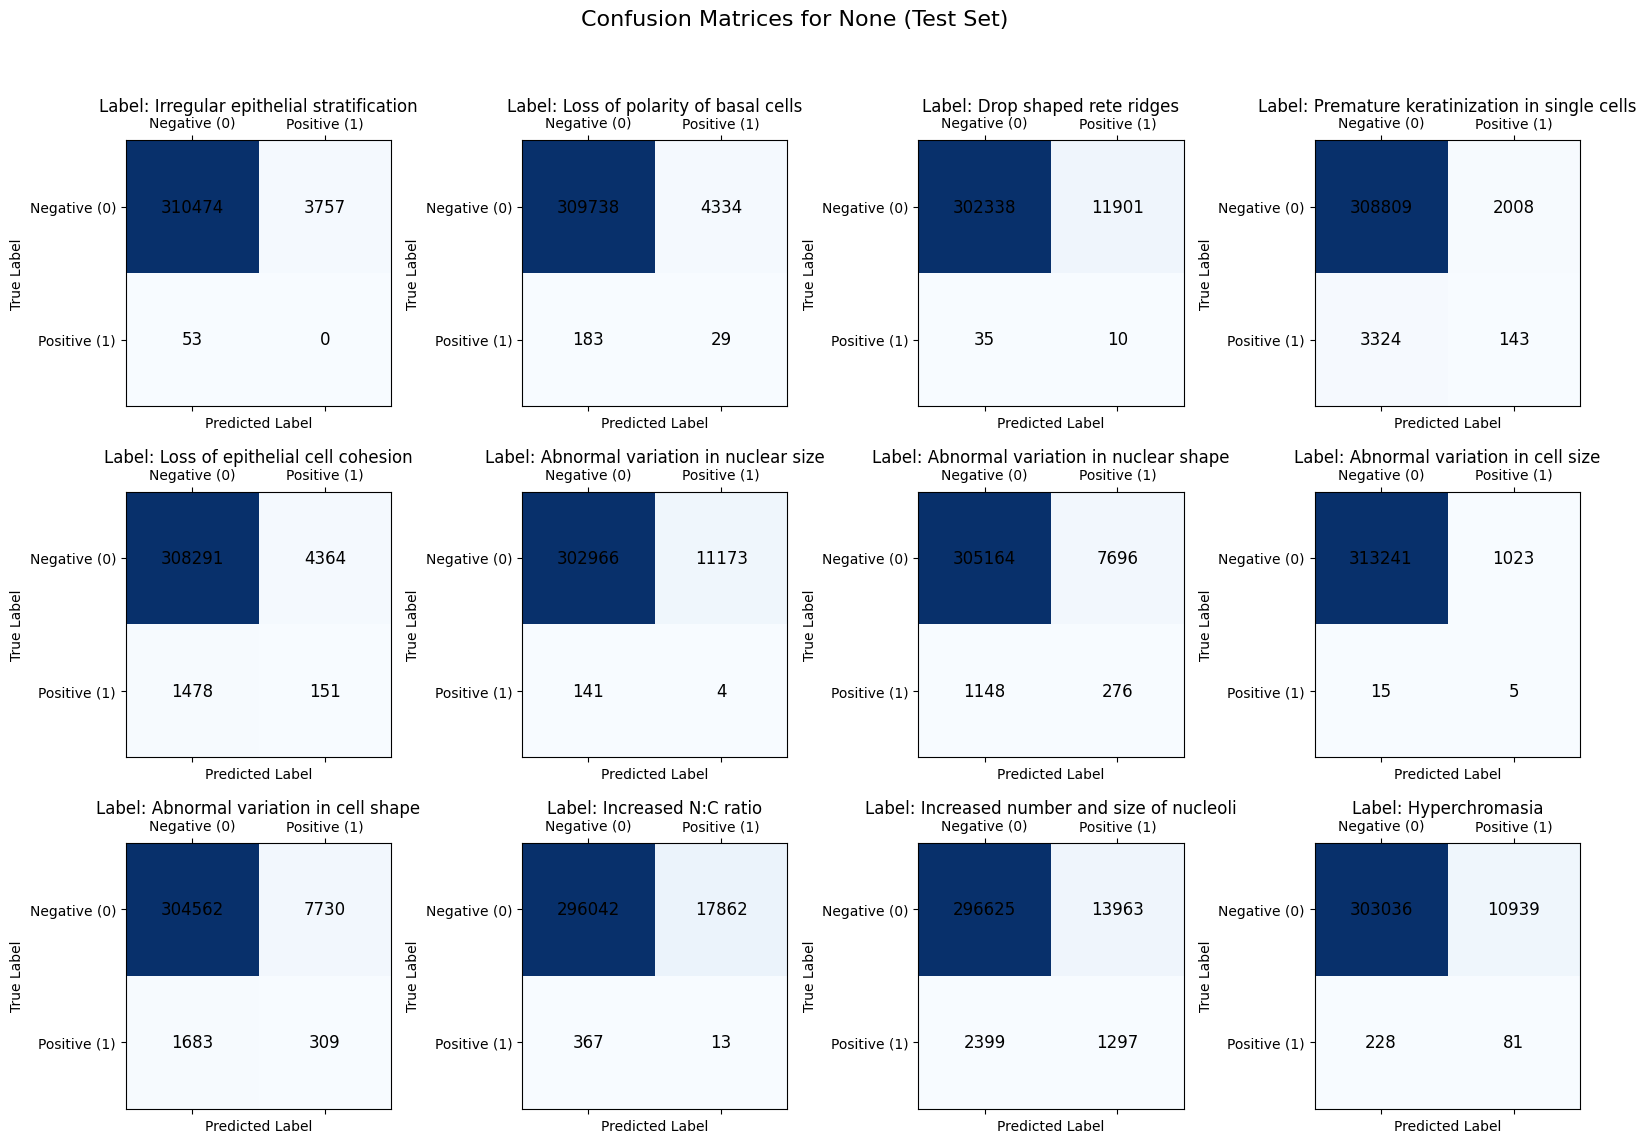



--- Final Test Results for None ---
| Test Micro AUC: 0.9104 | Test Macro AUC: 0.8829 |
-------------------------------------------------



================== FINAL AUROC SUMMARY ==================
Strategy            | Test Micro AUROC| Test Macro AUROC
-------------------------------------------------------
None                | 0.9104          | 0.8829          
-------------------------------------------------------
BEST STRATEGY (None) determined by Macro AUROC: 0.8829


In [14]:
# @title 50% - Square root Weight
# --- 5. Execution Block ---
base_path = str(RP50_DIR)
weight_type = "Sqr"
covertype = "50"

if __name__ == '__main__':
    # Load your DataFrames
    try:
        train_files = [f"{base_path}/final_df_train{i}.csv" for i in range(1, 11)]
        # train_df = pd.concat(
        #     [pd.read_csv(f, low_memory=False) for f in train_files],
        #     ignore_index=True
        # )
        # val_df = pd.read_csv(base_path +'/final_df_val.csv', low_memory=False)
        # test_df = pd.read_csv(base_path +'/final_df_test.csv', low_memory=False)
        # train_df = pd.read_csv(base_path +'/demo_df_train.csv')
        # val_df = pd.read_csv(base_path +'/demo_df_val.csv', low_memory=False)
        # test_df = pd.read_csv(base_path +'/demo_df_test.csv', low_memory=False)
        train_df = pd.concat(
            [pd.read_csv(f, low_memory=False) for f in train_files],
            ignore_index=True
        )
        val_df = pd.read_csv(base_path +'/final_df_val.csv', low_memory=False)
        test_df = pd.read_csv(base_path +'/final_df_test.csv', low_memory=False)

        # Replace Colab-style filepath with DICC filepath
        old_prefix = "/content/ResearchProject_50"
        new_prefix = str(RP50_DIR)

        for df in [train_df, val_df, test_df]:
            df["filepath"] = df["filepath"].astype(str).str.replace(
                old_prefix,
                new_prefix,
                regex=False
            )

        print("\nExample filepath after replacement:")
        print(train_df["filepath"].iloc[0])
        print("Exists:", Path(train_df["filepath"].iloc[0]).exists())

        assert Path(train_df["filepath"].iloc[0]).exists(), "Filepath replacement failed."
    except FileNotFoundError:
        print("ERROR: Please ensure df_train.csv, df_val.csv, and df_test.csv are in the current directory.")
        exit()

    # --- 2. Calculate pos_weight for BCEWithLogitsLoss (from IMbalanced data) ---
    print("Calculating pos_weight for loss function (from full imbalanced set)...")

    # Sum of positive labels for each class
    # print("Training")
    positive_counts = train_df[label_columns].sum()
    print(positive_counts)
    # print("Validation")
    # positive_counts1 = val_df[label_columns].sum()
    # print(positive_counts1)
    # print("Testing")
    # positive_counts2 = test_df[label_columns].sum()
    # print(positive_counts2)

    print("\n--- Setting up Label-aware Balanced Sampler ---")

    sampler = LabelAwareBalancedSampler(
        train_df=train_df,
        label_columns=label_columns,
        seed=SEED,
        replacement=True
    )

    n_abnormal = sampler.n_abnormal
    n_normal = sampler.n_normal
    num_train_samples = len(sampler)

    print(f"Dataset Counts: {n_abnormal} Abnormal, {n_normal} Normal")
    print(f"Sampler initialized with seed {SEED}. Epoch length: {num_train_samples} patches.")

    def seed_worker(worker_id):
        worker_seed = SEED + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(SEED)

    # ==============================================================================
    # 2. CALCULATE DAMPENED POS_WEIGHT (PASTE THE NEW CODE HERE)
    # ==============================================================================
    print("\n--- Calculating Dampened pos_weight for Loss Function ---")

    # 1. Get the intrinsic count of positive labels
    positive_counts = train_df[label_columns].sum()

    # 2. Calculate "Effective Negatives" based on the Sampler's 1:1 output
    #    In one epoch, total samples = (2 * n_abnormal)
    effective_negatives = (2 * n_abnormal) - positive_counts

    # 3. Calculate RAW weights first
    raw_weights = effective_negatives / (positive_counts + 1e-6)

    print("Raw Adjusted Weights (Too Aggressive):")
    print(raw_weights)

    # 4. THE FIX: Dampen the weights using Square Root
    #    This prevents the model from predicting "1" for everything.
    pos_weight = torch.sqrt(torch.tensor(raw_weights.values, dtype=torch.float32))

    # 5. Create the Loss Function
    pos_weight = pos_weight.to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print("\nDampened Weights (Using Sqrt):")
    for label, w in zip(label_columns, pos_weight):
        print(f"  '{label}': {w:.2f}")

    # Initialize Test and Validation Loaders (fixed transform)
    val_dataset = MultiLabelTileDataset(val_df, label_columns, transform=val_test_transform)
    test_dataset = MultiLabelTileDataset(test_df, label_columns, transform=val_test_transform)
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=loader_generator
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=loader_generator
    )

    final_results = {}

    # --- Run Loop for Hyperparameter Tuning ---
    for name, train_transform in AUGMENTATION_COMBINATIONS.items():
        # Setup TRAIN Dataset and Loader for current augmentation
        train_dataset = MultiLabelTileDataset(train_df, label_columns, transform=train_transform)
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            collate_fn=collate_fn,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=loader_generator
        )

        test_micro_auc, test_macro_auc = train_and_evaluate_run(
            model_name=name,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            num_classes=NUM_CLASSES,
            criterion=criterion,
            optimizer_class=torch.optim.AdamW,
            lr=LEARNING_RATE,
            num_epochs=EPOCHS,
            patience=PATIENCE,
            label_columns=label_columns,
            checkpoint_path=CHECKPOINT_PATH, # Passes the manual checkpoint path
            weight_type=weight_type,
            covertype=covertype
        )

        final_results[name] = {
            'micro': test_micro_auc,
            'macro': test_macro_auc
        }

    # --- Print Summary (Modified) ---
    print("\n\n================== FINAL AUROC SUMMARY ==================")
    # Define header widths (20 + 16 + 16)
    print(f"{'Strategy':<20}| {'Test Micro AUROC':<16}| {'Test Macro AUROC':<16}")
    print("-" * 55)

    best_macro_auc = -1
    best_strategy = ""

    for name, aucs in final_results.items():
        # 1. Retrieve the scores (assuming aucs is now a dictionary)
        micro_score = aucs['micro']
        macro_score = aucs['macro']

        # 2. Format the score into a string (e.g., '0.8500')
        micro_str = f"{micro_score:.4f}"
        macro_str = f"{macro_score:.4f}"

        # 3. Print, applying left-justified padding (the '<16') to the formatted string
        print(f"{name:<20}| {micro_str:<16}| {macro_str:<16}")

        # CHANGE: Track the best model based on MACRO PRC-AUC
        if aucs['macro'] > best_macro_auc:
            best_macro_auc = aucs['macro']
            best_strategy = name

    print("-" * 55)
    print(f"BEST STRATEGY ({best_strategy}) determined by Macro AUROC: {best_macro_auc:.4f}")
    print("=======================================================")

In [15]:
print("--- Positive Class Counts in VALIDATION Set ---")
print(val_df[label_columns].sum())

print("--- Positive Class Counts in Testing Set ---")
print(test_df[label_columns].sum())

--- Positive Class Counts in VALIDATION Set ---
Irregular epithelial stratification          376
Loss of polarity of basal cells              357
Drop shaped rete ridges                       86
Premature keratinization in single cells     449
Loss of epithelial cell cohesion             197
Abnormal variation in nuclear size          2313
Abnormal variation in nuclear shape         1924
Abnormal variation in cell size             1316
Abnormal variation in cell shape            1461
Increased N:C ratio                         1554
Increased number and size of nucleoli       1230
Hyperchromasia                               768
dtype: int64
--- Positive Class Counts in Testing Set ---
Irregular epithelial stratification           53
Loss of polarity of basal cells              212
Drop shaped rete ridges                       45
Premature keratinization in single cells    3467
Loss of epithelial cell cohesion            1629
Abnormal variation in nuclear size           145
Abnormal var

In [16]:
# --- Print Summary (Modified) ---
print("\n\n================== FINAL AUROC SUMMARY ==================")
# Define header widths (20 + 16 + 16)
print(f"{'Strategy':<20}| {'Test Micro AUROC':<16}| {'Test Macro AUROC':<16}")
print("-" * 55)

best_macro_auc = -1
best_strategy = ""

for name, aucs in final_results.items():
    # 1. Retrieve the scores (assuming aucs is now a dictionary)
    micro_score = aucs['micro']
    macro_score = aucs['macro']

    # 2. Format the score into a string (e.g., '0.8500')
    micro_str = f"{micro_score:.4f}"
    macro_str = f"{macro_score:.4f}"

    # 3. Print, applying left-justified padding (the '<16') to the formatted string
    print(f"{name:<20}| {micro_str:<16}| {macro_str:<16}")

    # CHANGE: Track the best model based on MACRO PRC-AUC
    if aucs['macro'] > best_macro_auc:
        best_macro_auc = aucs['macro']
        best_strategy = name

print("-" * 55)
print(f"BEST STRATEGY ({best_strategy}) determined by Macro AUROC: {best_macro_auc:.4f}")
print("=======================================================")



================== FINAL AUROC SUMMARY ==================
Strategy            | Test Micro AUROC| Test Macro AUROC
-------------------------------------------------------
None                | 0.9104          | 0.8829          
-------------------------------------------------------
BEST STRATEGY (None) determined by Macro AUROC: 0.8829
